In [ ]:
import math
import time
import numpy
import matplotlib.pyplot as plot

In [ ]:
# Problem 1

def leibniz(n):
    # Sum of the first n terms of the series in the Leibniz formula
    total_value = 0.0
    for i in range(n):
        total_value += (-1)**i / (2*i + 1)
    return total_value

x = 20
print(f"The sum of the first {x} terms =", leibniz(x))
print(f"The estimate of pi =", 4 * leibniz(x))

The sum of the first 20 terms = 0.77290595166696
The estimate of pi = 3.09162380666784


In [ ]:
# Problem 2

# 2(a) Use a for-loop and an if-statement with the modulo operator % to determine whether to add or subtract each term

def question_2a(n):
    total_value = 0.0
    for i in range(n):
        term = 1 / (2*i + 1)
        if i % 2 == 0:
            total_value += term
        else:
            total_value -= term
    return total_value

print(question_2a(20))

0.77290595166696


In [ ]:
# Problem 2

# 2(b) Use a Use a for-loop with the quantity (-1)**n to determine whether to add or subtract each term.

def question_2b(n):
    total_value = 0.0
    for i in range(n):
        total_value += (-1)**i * (1 / (2*i + 1))
    return total_value

print(question_2b(20))

0.77290595166696


In [ ]:
# Problem 2

# 2(c) Construct a Python list and compute the sum of the terms in the list.

def Question_2c(n):
    terms = []
    for i in range(n):
        terms.append((-1)**i / (2*i + 1))
    return sum(terms)

print(Question_2c(10))

0.7604599047323506


In [ ]:
# Problem 2

# 2(d) Construct a Python set and compute the sum of the terms in the set.

def question_2d(n):
    terms = set()
    for i in range(n):
        terms.add((-1)**i / (2*i + 1))
    return sum(terms)

print(question_2d(20))

0.7729059516669597


In [ ]:
# Problem 2

# 2(e) Construct a Python dictionary and compute the sum of the terms in the dictionary.

def question_2e(n):
    terms = {}
    for i in range(n):
        terms[i] = (-1)**i / (2*i + 1)
    return sum(terms.values())

print(question_2e(20))

0.7729059516669597


In [ ]:
# Problem 2

# 2(f) Construct a NumPy array and compute the sum of the terms in the array.

def question_2f(n):
    i = numpy.arange(n)
    terms = (-1.0)**i / (2*i + 1)
    return terms.sum()

print(question_2f(10))

0.7604599047323506


In [ ]:
# Problem 2

# 2(g) Construct a NumPy array, use array indexing to compute the sum of the positive terms in the array, use array indexing to compute
# the sum of the negative terms in the array, and add the two sums together. You can write x[::2] to access the first, third, etc.terms and x[1::2]
# to access the second, fourth, etc. terms.

def ques_2g(n):
    i = numpy.arange(n)
    terms = (-1.0)**i / (2*i + 1)
    positiveSum = terms[::2].sum()
    negativeSum = terms[1::2].sum()
    return positiveSum + negativeSum

print(ques_2g(20))



0.7729059516669594


In [ ]:
# Problem 2

# 2(j) Combine the first and second terms, the third and fourth terms, etc. to change this series from an alternating to a non-alternating series
# and compute the sum of the combined terms.

def question_2j(n):
    i = numpy.arange(n)
    terms = (-1.0)**i / (2*i + 1)
    evens = terms[::2]   # +ive
    odds = terms[1::2]   # -ive
    if len(odds) < len(evens):
        odds = numpy.concatenate([odds, [0.0]])
    combined = evens + odds
    return combined.sum()

print(question_2j(10))

0.7604599047323506


In [ ]:
# Problem 3

# Which of these implementations of the Leibniz formula is the most accurate, fastest, and/or clearest? Which function would you use to calculate π
# (and why)? You can use the. built-in constants math.pi or np.pi for assessing the accuracy of your functions and the time package or the %timeit
# command for timing.

a = 220000
all = {
    "Problem 1": leibniz,
    "2a": question_2a,
    "2b": question_2b,
    "2c": Question_2c,
    "2d": question_2d,
    "2e": question_2e,
    "2f": question_2f,
    "2g": ques_2g,
    "2j": question_2j,
}

timings = {}
for name, func in all.items():
    start = time.time()
    func(a)
    elapsed = time.time() - start
    timings[name] = elapsed
    print(f"{name:10s} {elapsed*1000:8.2f} ms")

Problem 1     48.88 ms
2a            24.11 ms
2b            51.27 ms
2c            64.85 ms
2d            85.75 ms
2e            70.86 ms
2f             3.38 ms
2g             3.18 ms
2j             3.14 ms


As we can see that 2f, 2g, and 2j are among the fast implementations and the fastest is 3.14 ms by 2j (for n = 220000).

I would use 2f to calculate pi because this is one of the fast and simple.And if we observe, we can see that 2g and 2j are also following the 2f implementation and they are built on top on 2f.

The accuaracy is same for all them they just use different code structure like numpy or list or loop.


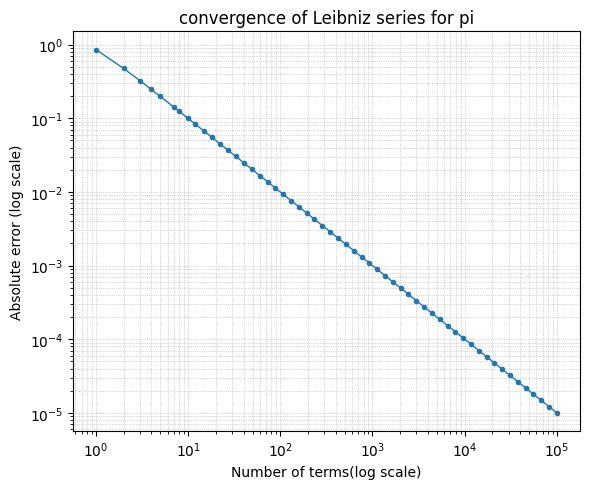

In [ ]:
# Problem 4

# Choose your favorite implementation of this formula, and plot the absolute error in the sum as a function of the number of terms in the sum.
# You should have accurate, informative, and legible labels for both the x-axis and y-axis, and you should use logarithmic axes or take the logarithm
# of the errors and the numbers of terms so that you can see the sums converge over a wide range of values. By default, most plotting packages generate
# large plots that are difficult to read in papers and presentations. Use a command like plt.figure(figsize=(2, 2)) to make your plot more legible.

n = numpy.unique(numpy.logspace(0, 5, num=60, dtype=int))
error = []
for i in n:
    pi_estimate = 4 * question_2f(int(i))
    error.append(abs(pi_estimate - math.pi))
error = numpy.array(error)

plot.figure(figsize=(6, 5))
plot.loglog(n, error, marker="o", markersize=3, linewidth=1)
plot.xlabel("Number of terms(log scale)")
plot.ylabel("Absolute error (log scale)")
plot.title("convergence of Leibniz series for pi")
plot.grid(True, which="both", linestyle=":", linewidth=0.5)
plot.tight_layout()
plot.show()